In [2]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import scipy
from neurolib.models.wc import WCModel

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
label_size= 30
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1
plt.rcParams['text.usetex'] = True

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Modern"
})

In [22]:
N = 100
with open(os.path.join(datadir, 'wb.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0, data_1, data_2] = data_read

with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0_L1, data_1_L1, data_2_L1] = data_read

with open(os.path.join(datadir, 'wb_cc.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0_cc, data_1_cc, data_2_cc] = data_read

with open(os.path.join(datadir, 'wb_cc_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0_cc_L1, data_1_cc_L1, data_2_cc_L1] = data_read

dt = 0.1

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

In [6]:
def get_period(x):
    peaks = scipy.signal.find_peaks(x, height=0.7)[0]
    pe_list = []

    for pi in range(len(peaks)-1):
        pe_list.append(peaks[pi+1] - peaks[pi])

    return np.mean(pe_list)

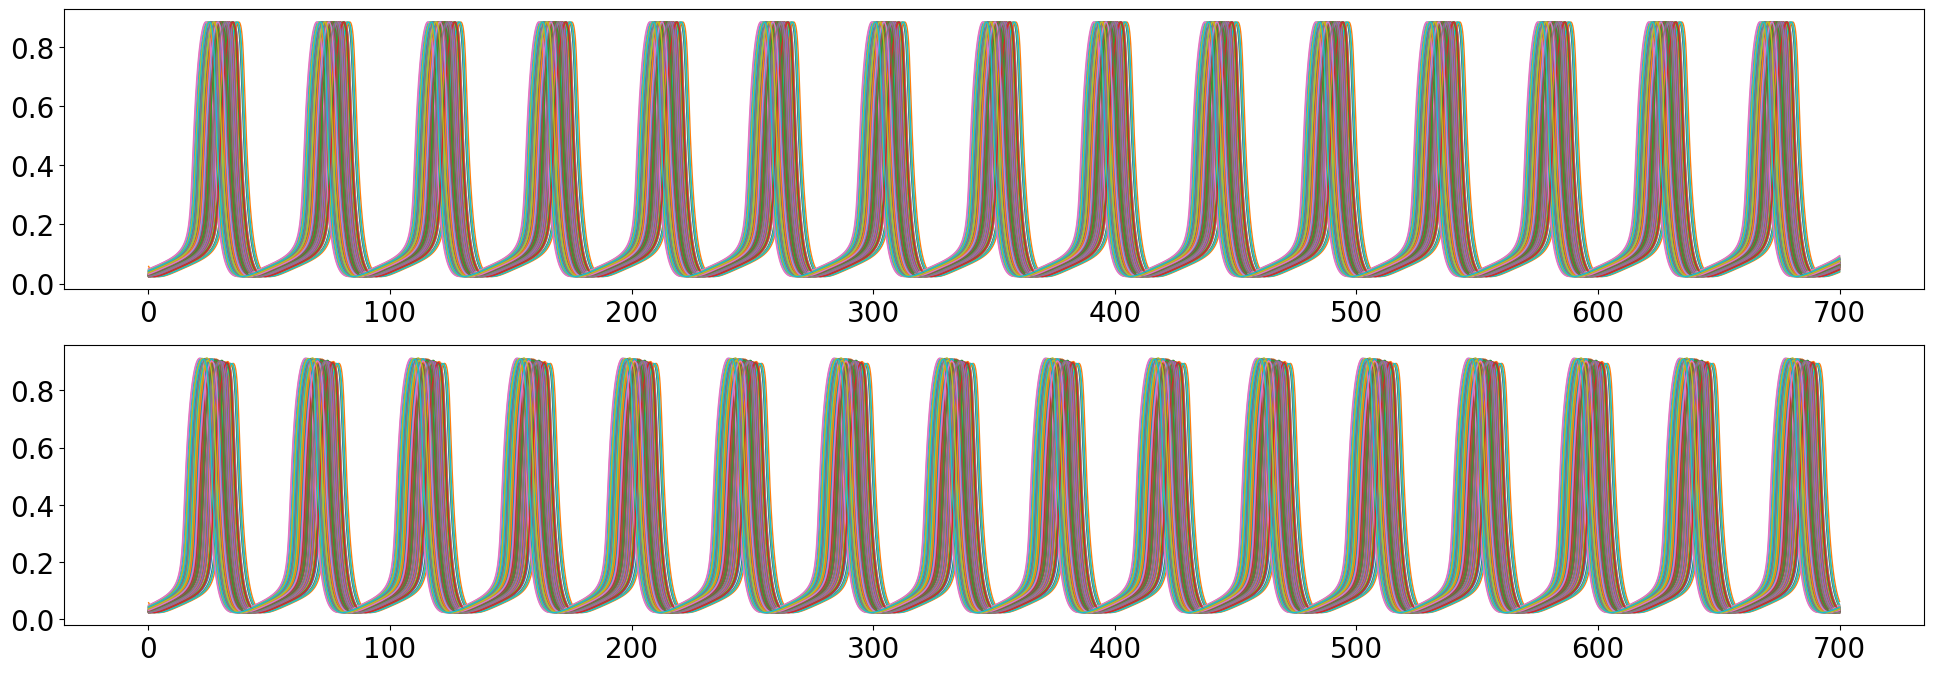

In [ ]:
duration = 700

fig, ax = plt.subplots(2,1, figsize=(24,8))

model = WCModel(Cmat=0.*cmat_av, Dmat=dmat_av)
time = np.arange(0,(duration+100)+dt, dt)
model.params.duration = duration
setparams(model)

d = data_0.copy()

model.params.exc_ext_baseline = d["coordinates"][0]
model.params.exc_inh_baseline = d["coordinates"][1]
model.params.exc_init = d["init_state"][0]
model.params.inh_init = d["init_state"][1]

model.run()

for n in range(N):
    ax[0].plot(model.t, model.exc[n,:])

model = WCModel(Cmat=1.*cmat_av, Dmat=dmat_av)
time = np.arange(0,(duration+100)+dt, dt)
model.params.duration = duration
setparams(model)

d = data_0.copy()

state = np.zeros((N, 1+int((duration+100)/dt)))
control = np.zeros((N, 1+int((duration+100)/dt)))

model.params.exc_ext_baseline = d["coordinates"][0]
model.params.exc_inh_baseline = d["coordinates"][1]
model.params.exc_init = d["init_state"][0]
model.params.inh_init = d["init_state"][1]

model.run()

for n in range(N):
    ax[1].plot(model.t, model.exc[n,:])

plt.show()


In [14]:
def norm_time(state, time):
    state_norm = np.zeros((len(time)))
   
    ratio = len(state[:])/len(time)

    if ratio == 1:
        state_norm = state.copy()
    elif ratio > 1:
        skip_ind = 1./(ratio-1.)
        t_count = 0
        mult_r = 0
        for t in range(len(time)):
            state_norm[t] = state[t_count]
            t_count += 1
            if t > mult_r*skip_ind:
                mult_r += 1
                t_count += 1
    else:
        repeat_ind = 1./(1.-ratio)
        t_count = 0
        mult_r = 0
        for t in range(len(time)):
            state_norm[t] = state[t_count]
            t_count += 1
            if t > np.floor(mult_r*repeat_ind):
                mult_r += 1
                t_count -= 1

    return state_norm

[352 811] 459.42857142857144
0.5267412935323383 0.06965174129353234
1.8980099502487562 1.3407960199004976


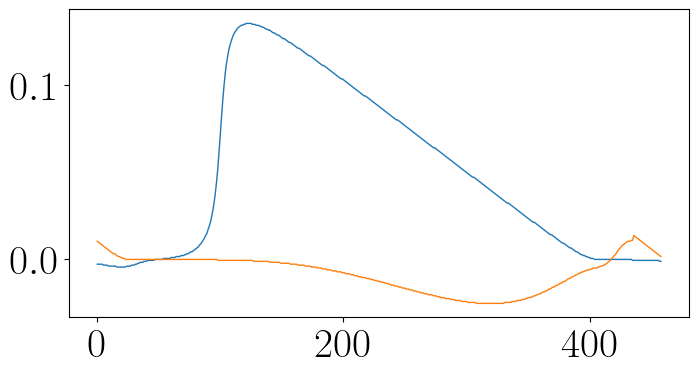

In [15]:
duration = 700

model = WCModel()

time = np.arange(0,(duration+100)+dt, dt)
model.params.duration = duration
setparams(model)

d = data_0.copy()

model.params.exc_ext_baseline = d["coordinates"][0]
model.params.exc_inh_baseline = d["coordinates"][1]
model.params.exc_init = (d["init_state"][0][0,:])[np.newaxis,:]
model.params.inh_init = (d["init_state"][1][0,:])[np.newaxis,:]

model.run()

x =  model.exc[0,:].copy()
period = get_period(x)
peaktimes0 = scipy.signal.find_peaks(x, height=0.7)[0][:2]
print(peaktimes0, period)

prp_plus = np.zeros(( int(period) ))
prp_minus = np.zeros(( int(period) ))

input = np.zeros_like(model.exc)
di = 5.
width = 2

for t in range(len(prp_plus)):
    input[0,peaktimes0[0]+t-width:peaktimes0[0]+t+width+1] += di
    model.params.exc_ext = input.copy()
    model.run()
    input[0,:] = 0.
    peaktimes1 = scipy.signal.find_peaks(model.exc[0,:1000])[0]
    prp_plus[t] = 2.*np.pi*(peaktimes0[1] - peaktimes1[-1])/(np.abs(di)*(2*width+1)*period)

for t in range(len(prp_minus)):
    input[0,peaktimes0[0]+t-width:peaktimes0[0]+t+width+1] -= di
    model.params.exc_ext = input.copy()
    model.run()
    input[0,:] = 0.
    peaktimes1 = scipy.signal.find_peaks(model.exc[0,:1000])[0]
    prp_minus[t] = 2.*np.pi*(peaktimes0[1] - peaktimes1[-1])/(np.abs(di)*(2*width+1)*period)

# pos: advance
# neg: delay

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(prp_plus)
ax.plot(prp_minus)

print(np.argmax(prp_plus)*2./(period), np.argmin(prp_plus)*2./(period))
print(np.argmax(prp_minus)*2./(period), np.argmin(prp_minus)*2./(period))

plt.show()

[265 647] 381.47058823529414
0.6029298380878951 0.06815728604471857
1.8192752505782575 1.3474171164225135


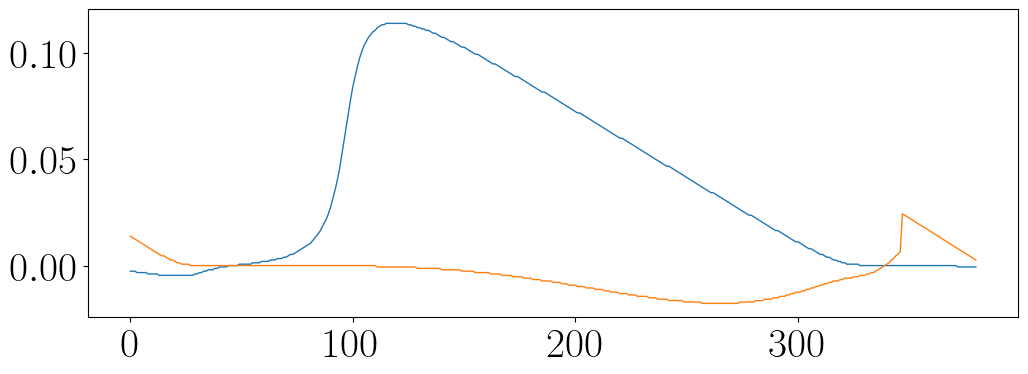

/tmp/ipykernel_461006/4048230707.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('nipy_spectral')


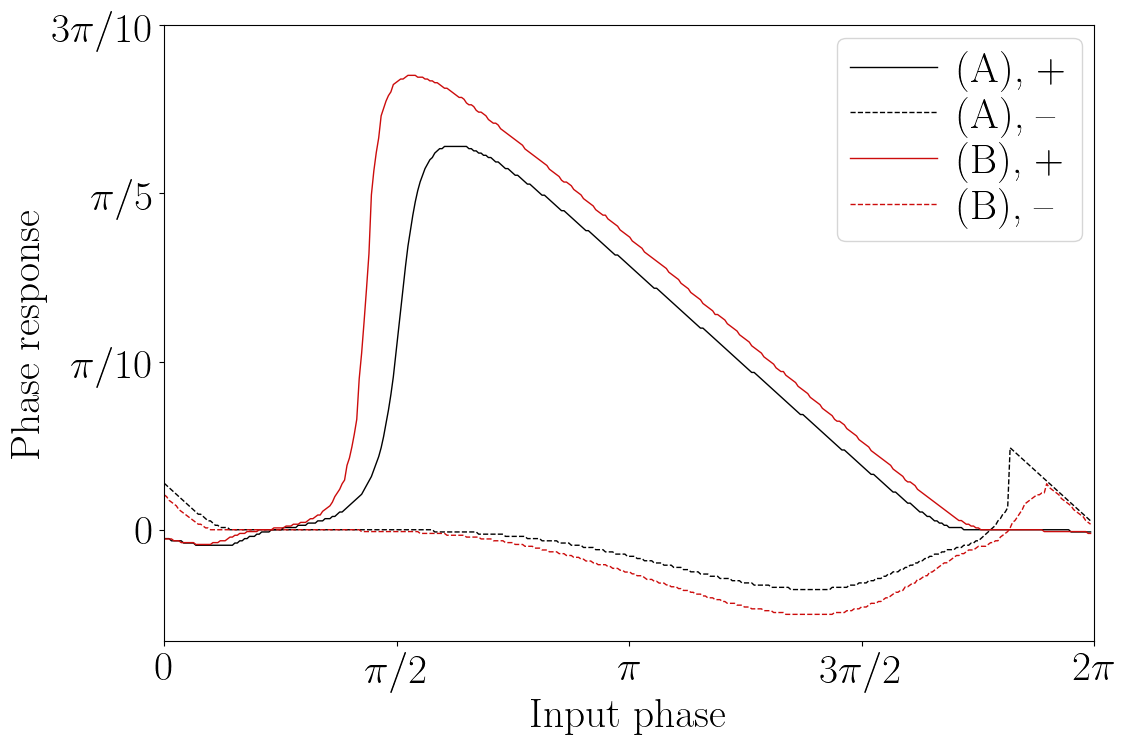

In [52]:
duration = 700

model = WCModel()

model.params.duration = duration
setparams(model)

d = data_2.copy()

model.params.exc_ext_baseline = d["coordinates"][0]
model.params.exc_inh_baseline = d["coordinates"][1]
model.params.exc_init = (d["init_state"][0][0,:])[np.newaxis,:]
model.params.inh_init = (d["init_state"][1][0,:])[np.newaxis,:]

model.run()

x =  model.exc[0,:].copy()
period = get_period(x)
peaktimes0 = scipy.signal.find_peaks(x, height=0.7)[0][:2]
print(peaktimes0, period)

prp_plus_A = np.zeros(( int(period) ))
prp_minus_A = np.zeros(( int(period) ))

input = np.zeros_like(model.exc)
di = 5.
width = 2

for t in range(len(prp_plus_A)):

    input[0,peaktimes0[0]+t-width:peaktimes0[0]+t+width+1] += di
    model.params.exc_ext = input.copy()
    model.run()
    input[0,:] = 0.
    peaktimes1 = scipy.signal.find_peaks(model.exc[0,:1000], height=0.7)[0]
    if peaktimes1[-1] > 800: peaktimes1 = peaktimes1[:-1]
    prp_plus_A[t] = 2.*np.pi*(peaktimes0[1] - peaktimes1[-1])/(np.abs(di)*(2*width+1)*period)

for t in range(len(prp_minus_A)):
    input[0,peaktimes0[0]+t-width:peaktimes0[0]+t+width+1] -= di
    model.params.exc_ext = input.copy()
    model.run()
    input[0,:] = 0.
    peaktimes1 = scipy.signal.find_peaks(model.exc[0,:1000], height=0.7)[0]
    if peaktimes1[-1] > 800: peaktimes1 = peaktimes1[:-1]
    prp_minus_A[t] = 2.*np.pi*(peaktimes0[1] - peaktimes1[-1])/(np.abs(di)*(2*width+1)*period)

# pos: advance
# neg: delay

fig, ax = plt.subplots(1,1, figsize=(12,4))
ax.plot(prp_plus_A)
ax.plot(prp_minus_A)

print(np.argmax(prp_plus_A)*2./(period), np.argmin(prp_plus_A)*2./(period))
print(np.argmax(prp_minus_A)*2./(period), np.argmin(prp_minus_A)*2./(period))
plt.show()

colmap = mpl.cm.get_cmap('nipy_spectral')
fig, ax = plt.subplots(1,1, figsize=(12,8))

time_A = np.arange(0,period*dt-dt, dt)
prp_plus = norm_time(prp_plus, time_A)
prp_minus = norm_time(prp_minus, time_A)


ax.plot(time_A, prp_plus_A, label="(A), +",color=colmap(0.))
ax.plot(time_A, prp_minus_A, color=colmap(0.), linestyle="--", label="(A), --")
ax.plot(time_A, prp_plus, color=colmap(0.95), label="(B), +")
ax.plot(time_A, prp_minus, color=colmap(0.95), linestyle="--", label="(B), --")

ax.set_xlim(0,period*dt)
ax.set_xticks([0, 0.25*(period*dt), 0.5*(period*dt), 0.75*(period*dt), (period*dt)])
ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

ax.set_yticks([ 0, 0.05, 0.1, 0.15])
ax.set_yticklabels(["0", r"$\pi/10$", r"$\pi/5$", r"$3\pi/10$"])

ax.legend(loc="upper right")
ax.set_xlabel("Input phase")
ax.set_ylabel("Phase response")

ax.legend(loc="upper right", labelspacing=0.1, handlelength=2.1, handletextpad=0.5, borderpad=0.3, borderaxespad=0.3)
plt.savefig(os.path.join(datadir, "prc.jpg"), bbox_inches='tight', dpi=300)
plt.show()

-600.0


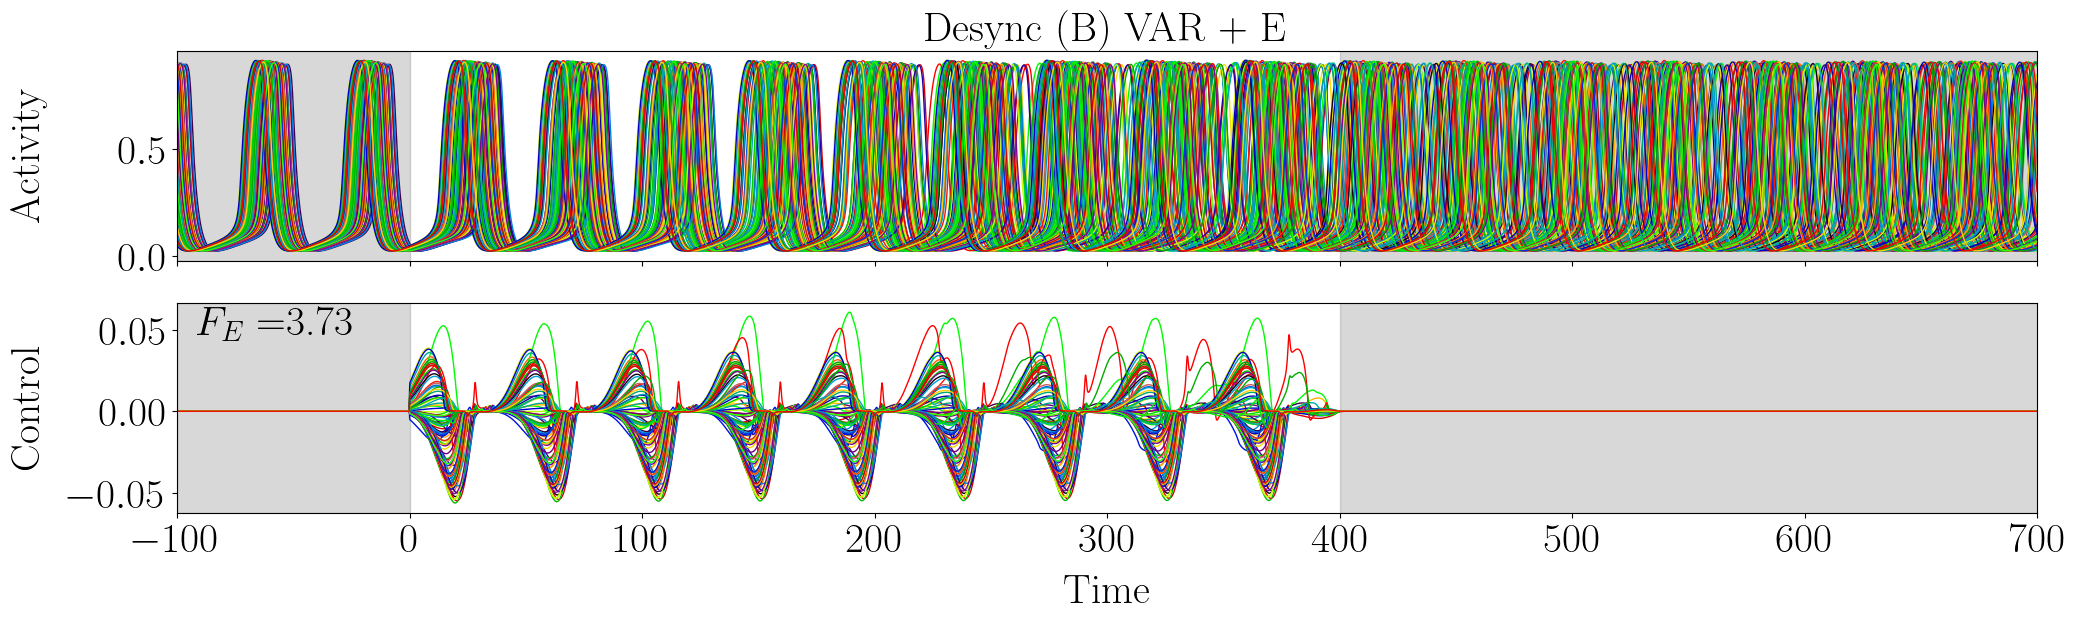

1000.0


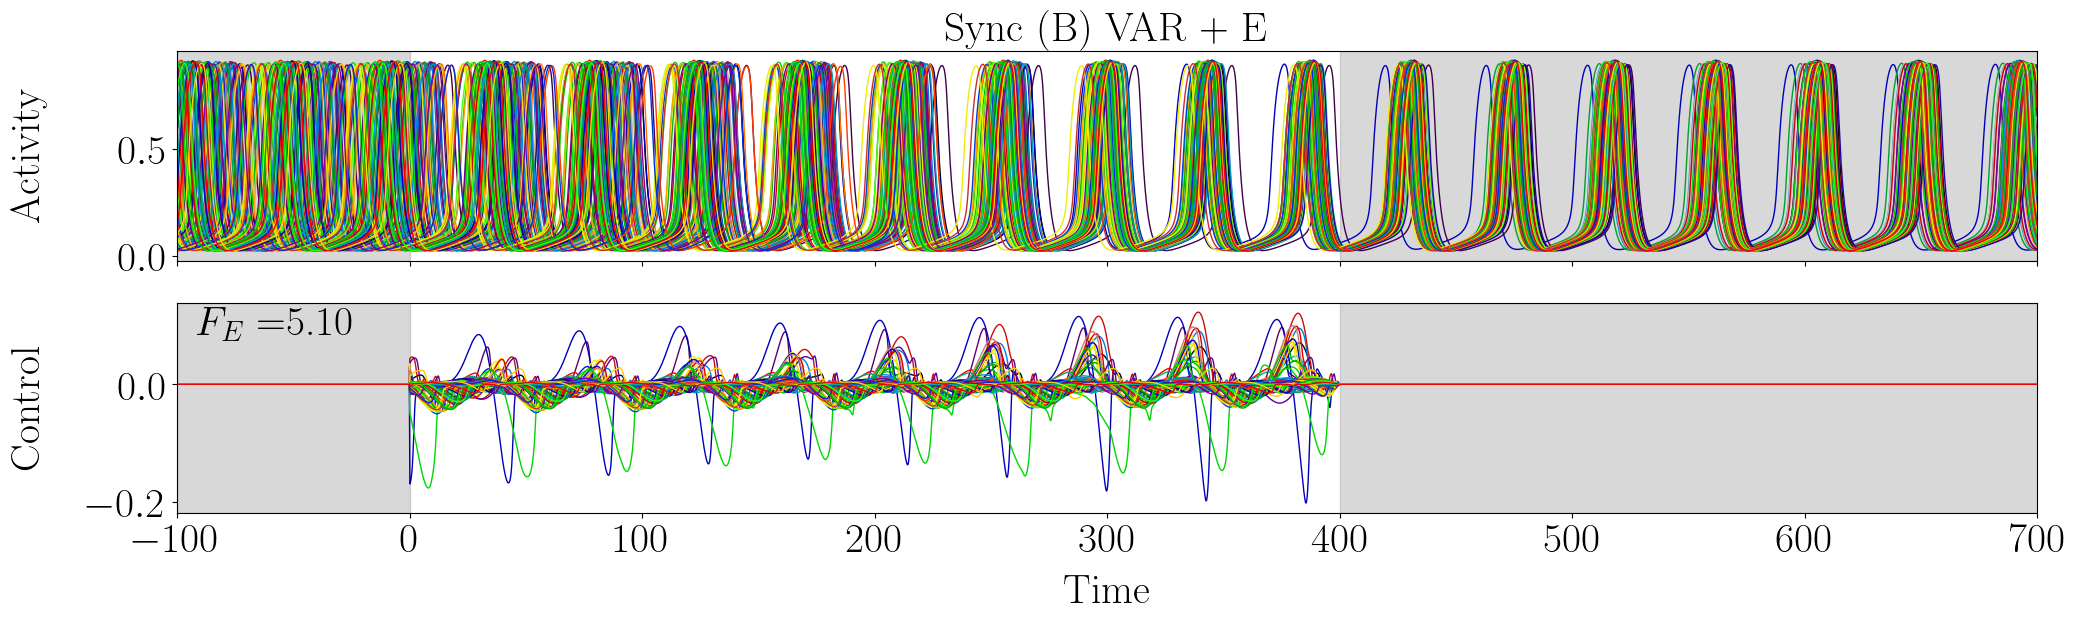

-2000.0


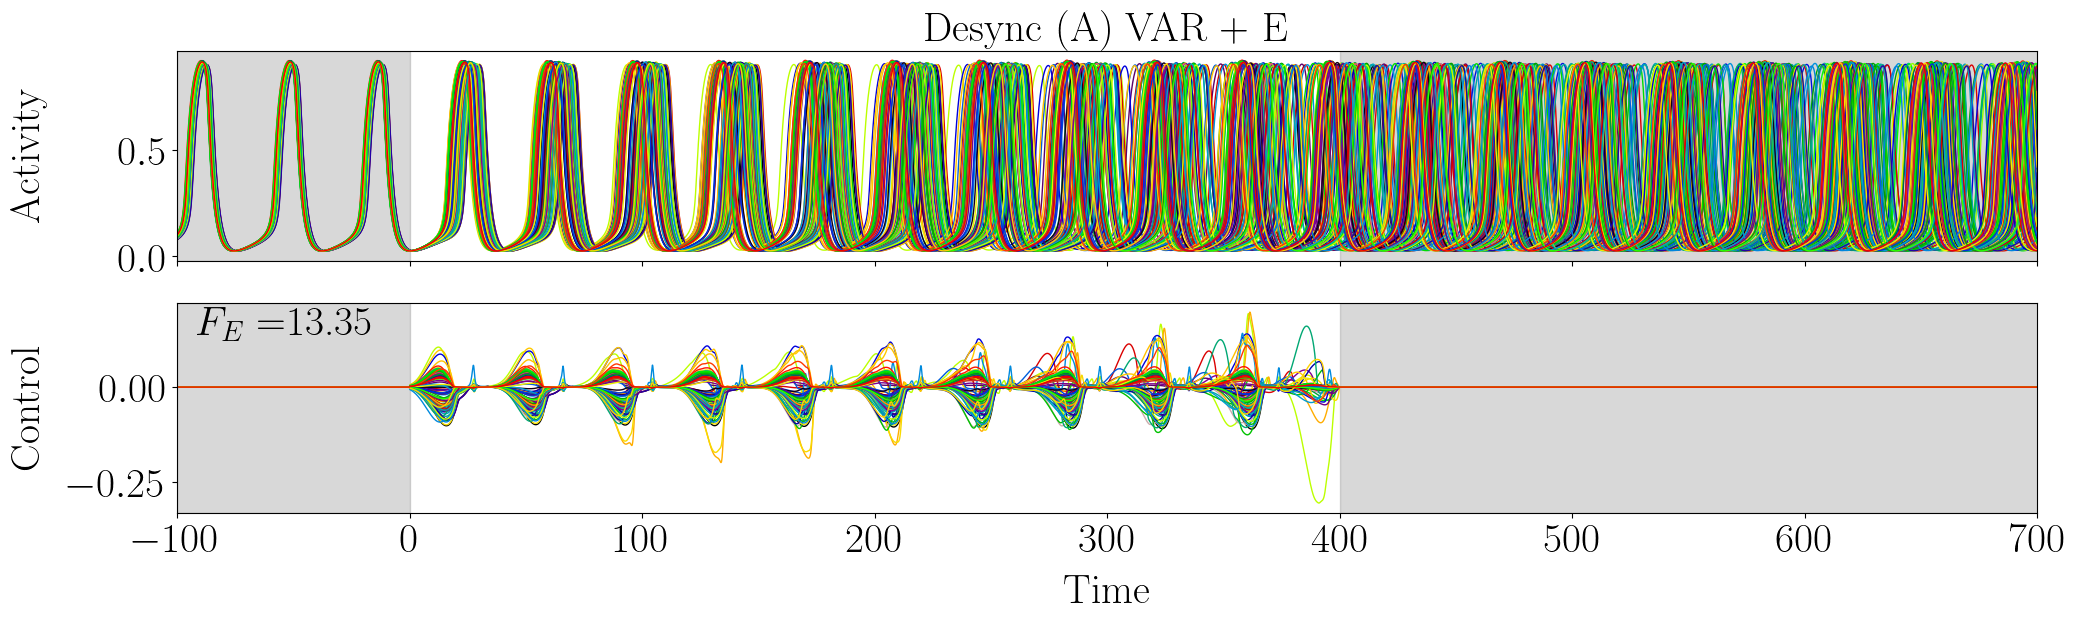

In [ ]:
duration = 700
alpha=0.3

model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
time = np.arange(-100.,(duration)+dt, dt)

model.params.duration = duration
setparams(model)

filename = ["B_desync_var_E", "B_sync_var_E", "A_desync_var_E"]

for id, d in enumerate([data_0, data_1, data_2]):

    wi =2

    print(d["weights"][wi])

    state = np.zeros((N, 1+int((duration+100)/dt)))
    control = np.zeros((N, 1+int((duration+100)/dt)))

    model.params.exc_ext_baseline = d["coordinates"][0]
    model.params.exc_inh_baseline = d["coordinates"][1]
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]

    control[:,1000:5001] = d["control"][wi][:,0,:]
    model.params.exc_ext = control.copy()

    model.run()


    fig, ax = plt.subplots(2,1, figsize=(24,6), sharex=True)

    for n in range(N):
        state[n,:1001] = d["state_uncontrolled"][n,0,-1001:]
        state[n,1001:] = model.exc[n,:]

        ax[0].plot(time, state[n,:])
        ax[1].plot(time, control[n,:])

    ax[0].set_xlim(time[0], time[-1])

    for k in range(2):
        ax[k].axvspan(-100, 0, color="grey", alpha=alpha)
        ax[k].axvspan(400, 800, color="grey", alpha=alpha)
    ax[1].text(0.01, 0.85, r"$F_E = $" + "{0:.2f}".format(d["energy_input"][wi]), transform=ax[1].transAxes)

    ax[1].set_xlabel("Time", labelpad=10)
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control", labelpad=10)
    ax[0].yaxis.set_label_coords(-0.07,.5)
    ax[1].yaxis.set_label_coords(-0.07,.5)

    if id == 0:
        ax[0].set_title("Desync (B) VAR + E")
    elif id == 1:
        ax[0].set_title("Sync (B) VAR + E")
    elif id == 2:
        ax[0].set_title("Desync (A) VAR + E")

    #fig.align_ylabels([ax[:]])
    plt.savefig(os.path.join(datadir, filename[id] + ".jpg"), bbox_inches='tight', dpi=300)
    plt.show()

-10.0


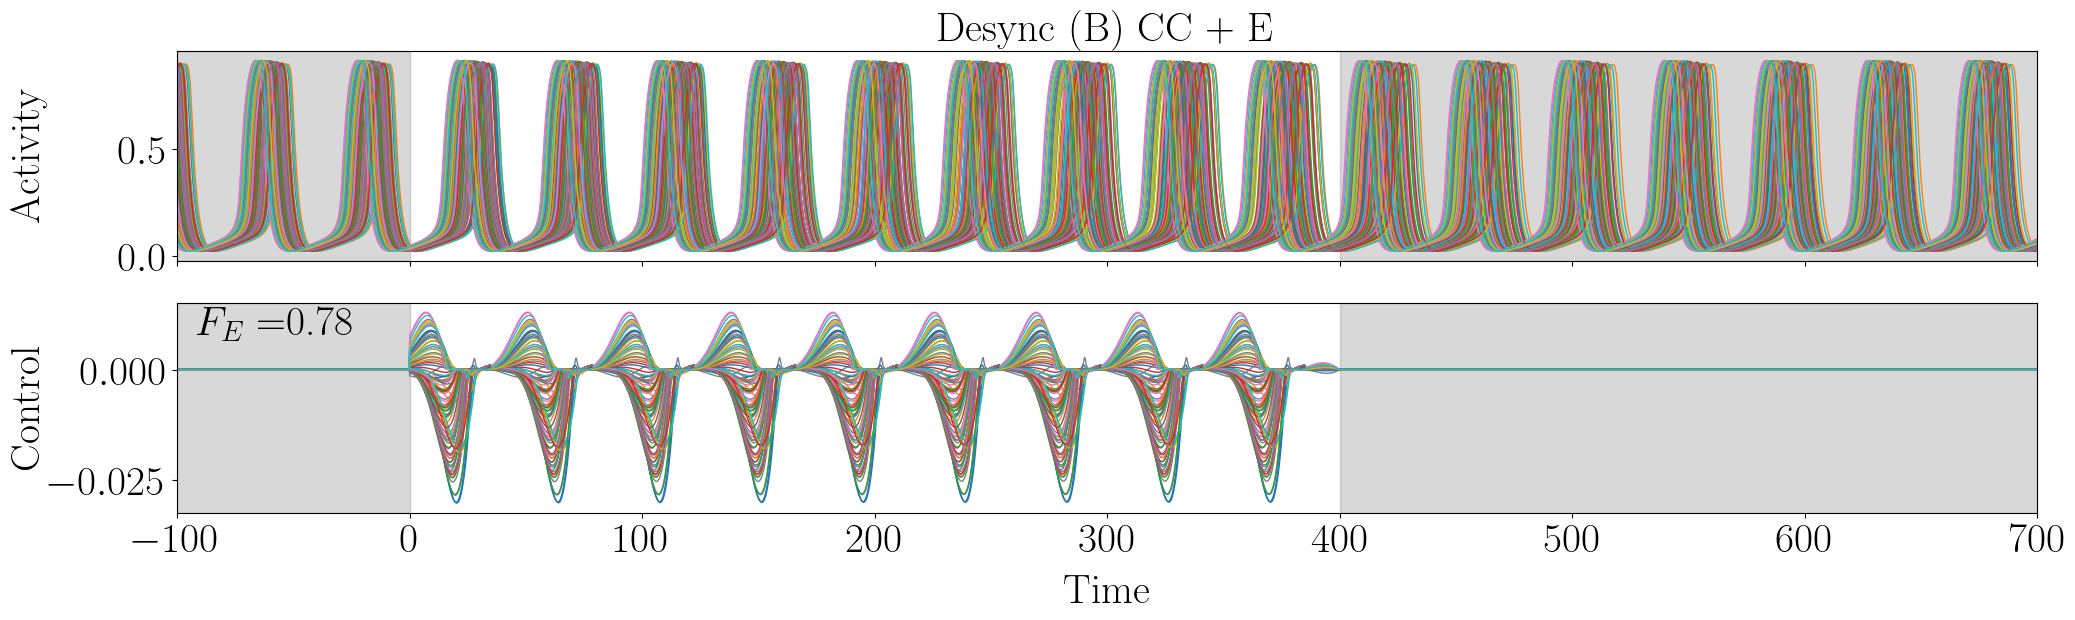

10.0


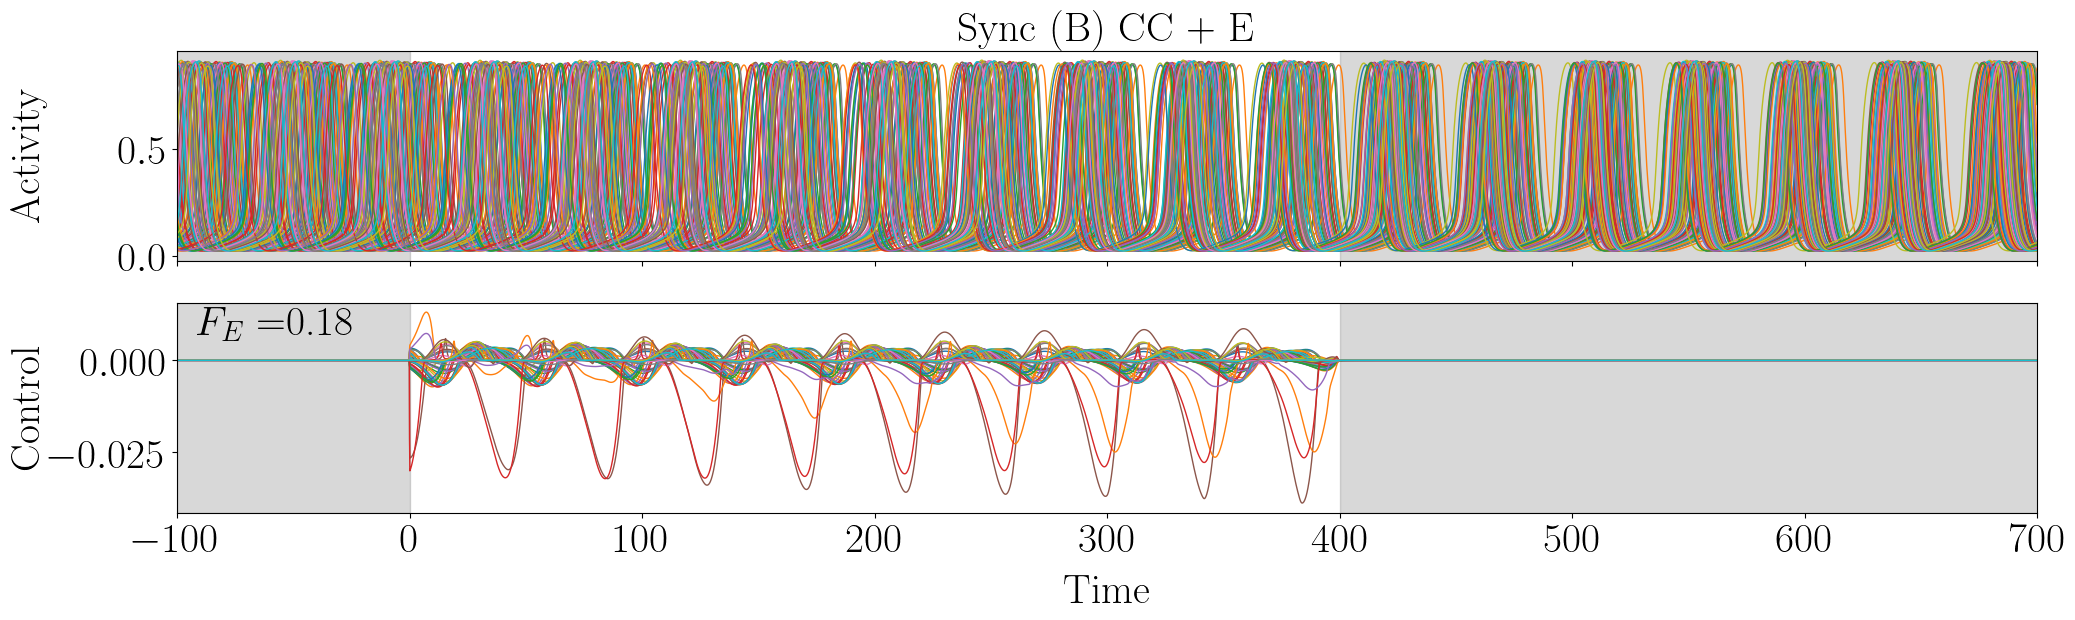

-30.0


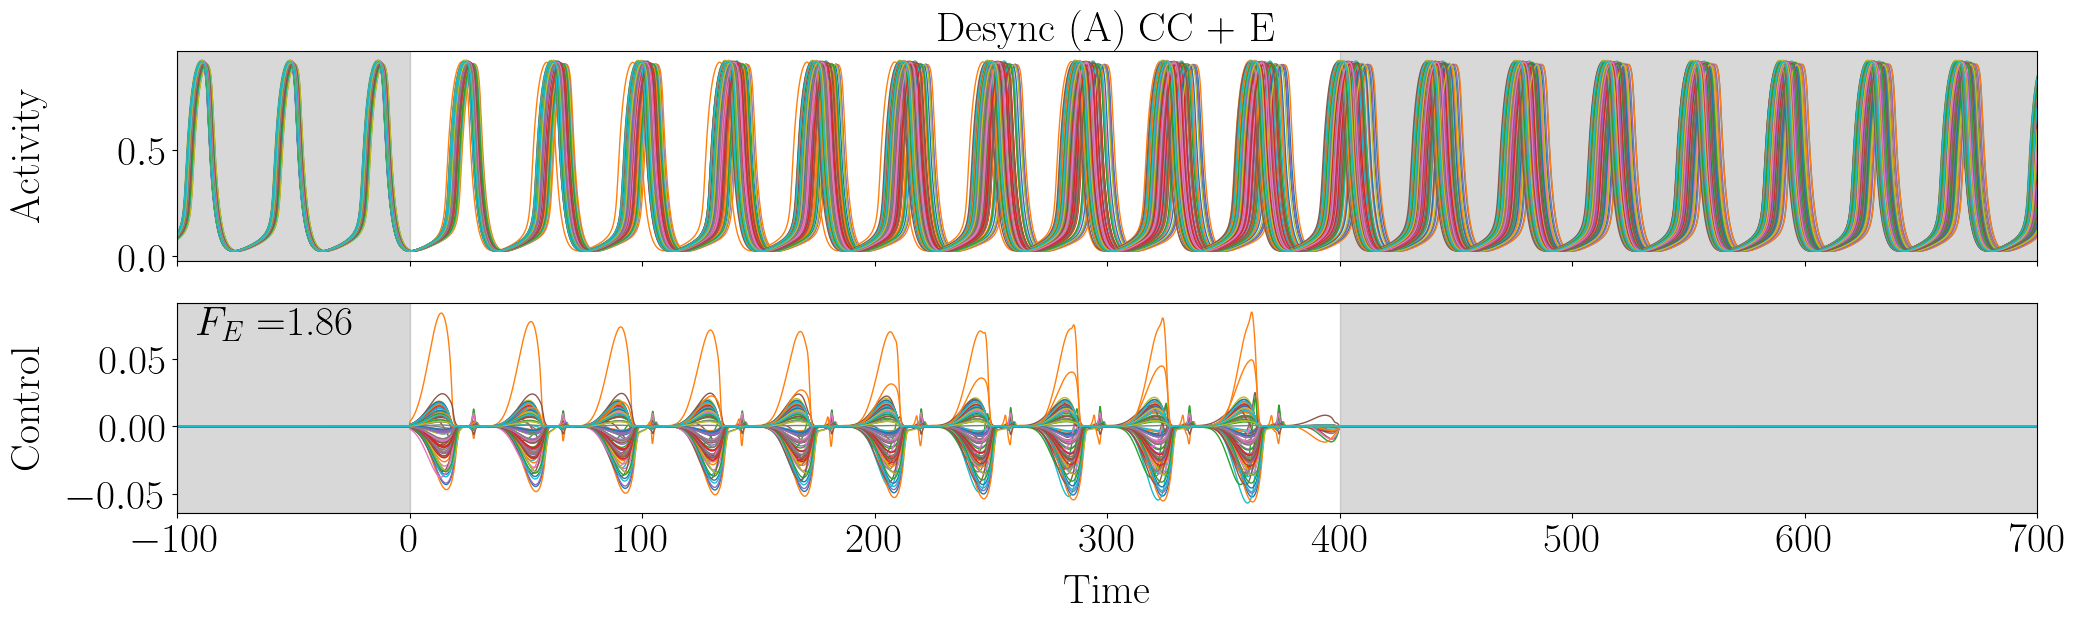

In [26]:
duration = 700
alpha=0.3

model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
time = np.arange(-100,(duration)+dt, dt)

model.params.duration = duration
setparams(model)

filename = ["B_desync_cc_E", "B_sync_cc_E", "A_desync_cc_E"]

for id, d in enumerate([data_0_cc, data_1_cc, data_2_cc]):

    wi = 0
    #if id in [1,2]: wi = 2

    print(d["weights"][wi])

    state = np.zeros((N, 1+int((duration+100)/dt)))
    control = np.zeros((N, 1+int((duration+100)/dt)))

    model.params.exc_ext_baseline = d["coordinates"][0]
    model.params.exc_inh_baseline = d["coordinates"][1]
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]

    control[:,1000:5001] = d["control"][wi][:,0,:]
    model.params.exc_ext = control.copy()

    model.run()

    fig, ax = plt.subplots(2,1, figsize=(24,6), sharex=True)

    for n in range(N):
        state[n,:1001] = d["state_uncontrolled"][n,0,-1001:]
        state[n,1001:] = model.exc[n,:]

        ax[0].plot(time, state[n,:])
        ax[1].plot(time, control[n,:])

    ax[0].set_xlim(time[0], time[-1])

    for k in range(2):
        ax[k].axvspan(-100, 0, color="grey", alpha=alpha)
        ax[k].axvspan(400, 800, color="grey", alpha=alpha)
    ax[1].text(0.01, 0.85, r"$F_E = $" + "{0:.2f}".format(d["energy_input"][wi]), transform=ax[1].transAxes)

    ax[1].set_xlabel("Time", labelpad=10)
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control", labelpad=10)
    ax[0].yaxis.set_label_coords(-0.07,.5)
    ax[1].yaxis.set_label_coords(-0.07,.5)

    if id == 0:
        ax[0].set_title("Desync (B) CC + E")
    elif id == 1:
        ax[0].set_title("Sync (B) CC + E")
    elif id == 2:
        ax[0].set_title("Desync (A) CC + E")

    fig.align_ylabels([ax[:]])
    plt.savefig(os.path.join(datadir, filename[id] + ".jpg"), bbox_inches='tight', dpi=300)
    plt.show()

-28.0


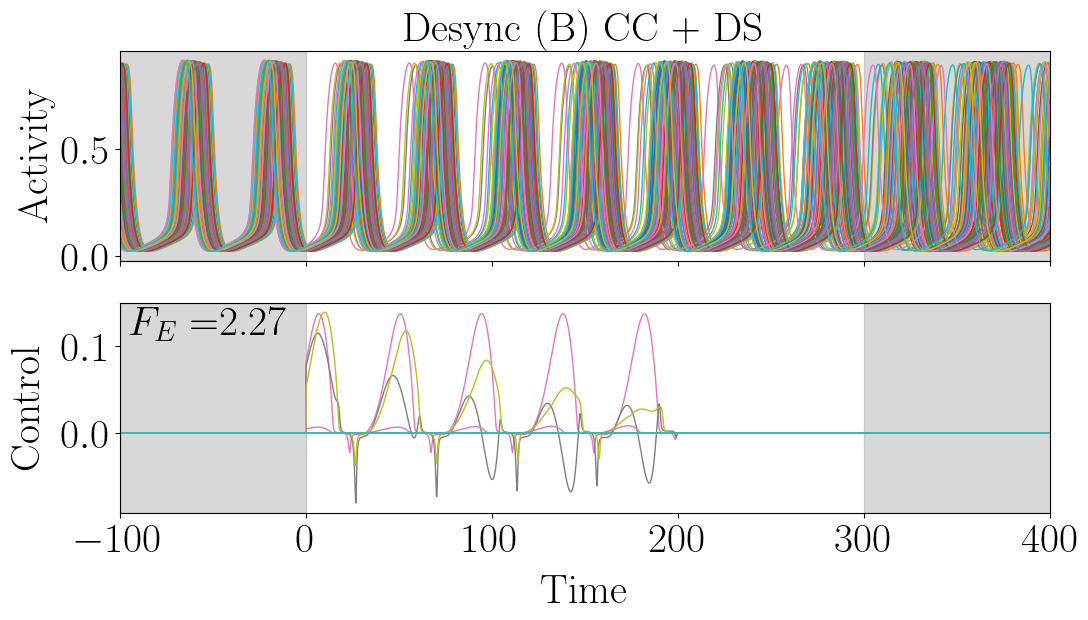

130.0


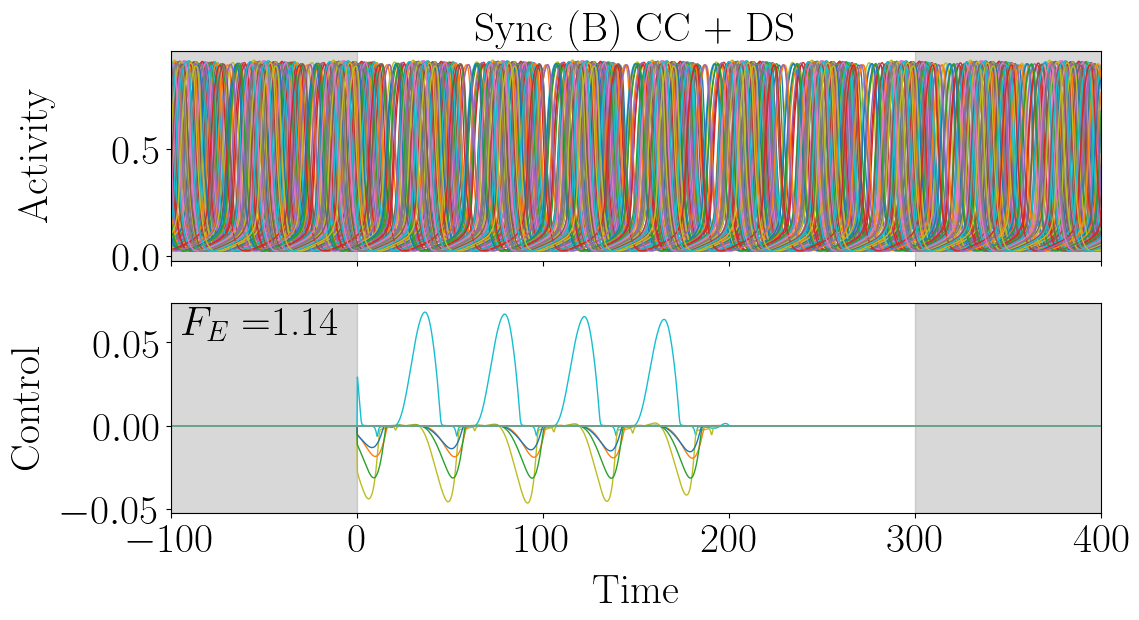

-34.0


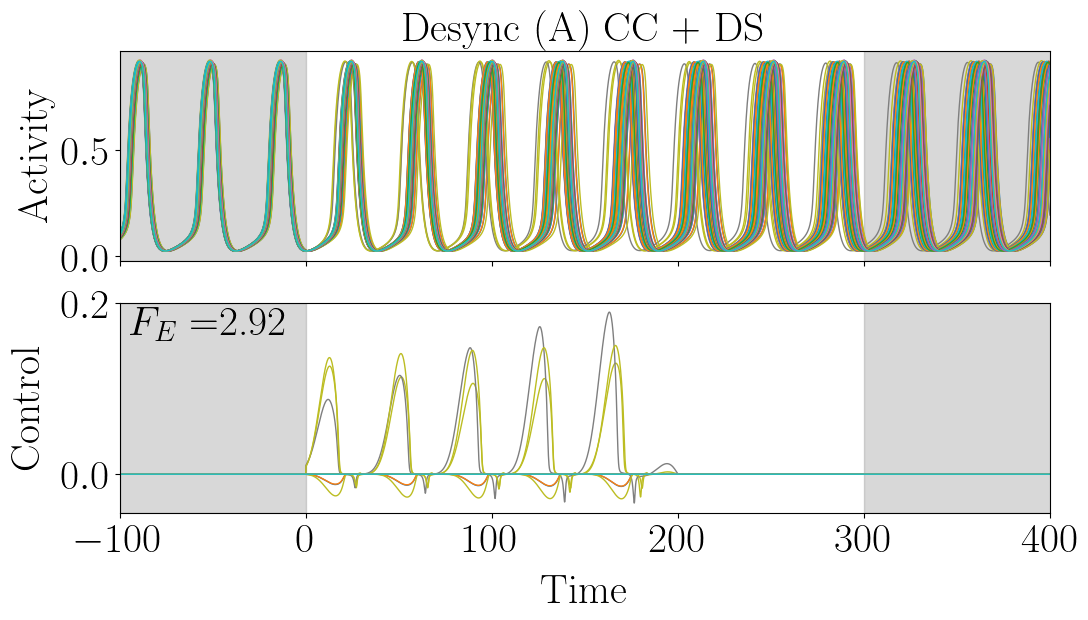

In [11]:
duration = 400
alpha=0.3

model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
time = np.arange(-100,(duration)+dt, dt)

model.params.duration = duration
setparams(model)

filename = ["B_desync_cc_DS", "B_sync_cc_DS", "A_desync_cc_DS"]

for id, d in enumerate([data_0_cc_L1, data_1_cc_L1, data_2_cc_L1]):

    wi = 1
    #if id in [1,2]: wi = 2

    print(d["weights"][wi])

    state = np.zeros((N, 1+int((duration+100)/dt)))
    control = np.zeros((N, 1+int((duration+100)/dt)))

    model.params.exc_ext_baseline = d["coordinates"][0]
    model.params.exc_inh_baseline = d["coordinates"][1]
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]

    control[:,1000:3001] = d["control"][wi][:,0,:]
    model.params.exc_ext = control.copy()

    model.run()

    fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)

    for n in range(N):
        state[n,:1001] = d["state_uncontrolled"][n,0,-1001:]
        state[n,1001:] = model.exc[n,:]

        ax[0].plot(time, state[n,:])
        ax[1].plot(time, control[n,:])

    ax[0].set_xlim(time[0], time[-1])

    for k in range(2):
        ax[k].axvspan(-100, 0, color="grey", alpha=alpha)
        ax[k].axvspan(300, 500, color="grey", alpha=alpha)
    ax[1].text(0.01, 0.85, r"$F_E = $" + "{0:.2f}".format(d["energy_input"][wi]), transform=ax[1].transAxes)

    ax[1].set_xlabel("Time", labelpad=10)
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control", labelpad=10)

    if id == 0:
        ax[0].set_title("Desync (B) CC + DS")
    elif id == 1:
        ax[0].set_title("Sync (B) CC + DS")
    elif id == 2:
        ax[0].set_title("Desync (A) CC + DS")

    fig.align_ylabels([ax[:]])
    plt.savefig(os.path.join(datadir, filename[id] + ".jpg"), bbox_inches='tight', dpi=300)
    plt.show()